# CNN on 3-channel mel-spectrograms (with deltas)

This notebook keeps the same architecture as Model 1 (1-channel CNN), but takes 3-channel input:

    - Channel 1: mel-spectrogram (what the sound is)
    - Channel 2: delta (how it's changing)
    - Channel 3: delta-delta (how fast that change is changing)

This tests whether the extra rate-of-change information helps the model
recognize emotions, especially with the speaker generalization challenge.

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Config

In [3]:
TRAIN_CSV = "train_split.csv"
VAL_CSV   = "val_split.csv"
TEST_CSV  = "test_split.csv"

MEL_PATH_COL = "mel3_path"
LABEL_COL    = "label"

NUM_CLASSES  = 7
BATCH_SIZE   = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-3
NUM_EPOCHS   = 50
PATIENCE     = 10
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loading Dataset

In [4]:
class MelSpectrogram3ChannelDataset(Dataset):
    """
    Loads 3-channel mel-spectrogram .npy files.

    Each .npy file has shape (3, 128, T) — three stacked layers:
        - layer 0: log-mel-spectrogram
        - layer 1: delta (first derivative)
        - layer 2: delta-delta (second derivative)
    """

    def __init__(self, source, mel_col=MEL_PATH_COL, label_col=LABEL_COL,
                 max_len=130, augment=False):
        if isinstance(source, str):
            self.df = pd.read_csv(source)
        else:
            self.df = source.copy()
        self.mel_col = mel_col
        self.label_col = label_col
        self.max_len = max_len
        self.augment = augment
        self.df = self.df.dropna(subset=[mel_col, label_col]).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mel = np.load(row[self.mel_col])  # Shape: (3, 128, T)

        # Pad or truncate the time dimension
        if mel.shape[2] < self.max_len:
            pad_width = self.max_len - mel.shape[2]
            mel = np.pad(mel, ((0, 0), (0, 0), (0, pad_width)), mode="constant")
        else:
            mel = mel[:, :, :self.max_len]

        # Normalize each channel independently
        for c in range(mel.shape[0]):
            mean = mel[c].mean()
            std = mel[c].std()
            if std > 0:
                mel[c] = (mel[c] - mean) / std

        # SpecAugment — applied to all three channels identically
        if self.augment:
            t_width = np.random.randint(5, 25)
            t_start = np.random.randint(0, max(1, mel.shape[2] - t_width))
            mel[:, :, t_start:t_start + t_width] = 0

            f_width = np.random.randint(5, 20)
            f_start = np.random.randint(0, max(1, mel.shape[1] - f_width))
            mel[:, f_start:f_start + f_width, :] = 0

        return torch.FloatTensor(mel), torch.LongTensor([int(row[self.label_col])]).squeeze()

# 3-Channel CNN Model

In [5]:
class EmotionCNN(nn.Module):
    """
    Identical architecture to Model 1 — only the first conv layer changes.
    Keeping everything else the same gives us a fair comparison.
    """

    def __init__(self, num_classes=NUM_CLASSES, in_channels=3):
        super(EmotionCNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Training Functions

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for mel, labels in loader:
        mel, labels = mel.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(mel)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * mel.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / len(loader.dataset), f1_score(all_labels, all_preds, average="weighted")

In [7]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for mel, labels in loader:
            mel, labels = mel.to(device), labels.to(device)
            outputs = model(mel)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * mel.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return (running_loss / len(loader.dataset),
            f1_score(all_labels, all_preds, average="weighted"),
            all_preds, all_labels)

In [8]:
def plot_training_curves(train_losses, val_losses, train_f1s, val_f1s, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(train_losses) + 1)
    ax1.plot(epochs, train_losses, "b-", label="Train Loss", linewidth=2)
    ax1.plot(epochs, val_losses, "r-", label="Val Loss", linewidth=2)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title("Model 2 (3-Channel) — Training vs Validation Loss")
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(epochs, train_f1s, "b-", label="Train F1", linewidth=2)
    ax2.plot(epochs, val_f1s, "r-", label="Val F1", linewidth=2)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Weighted F1")
    ax2.set_title("Model 2 (3-Channel) — Training vs Validation F1")
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved training curves to {save_path}")
    plt.show()

In [9]:
def plot_confusion_matrix(labels, preds, label_names, save_path=None):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title("Model 2 (3-Channel) — Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved confusion matrix to {save_path}")
    plt.show()

# Run 3-Channel CNN

In [10]:
print(f"Device: {DEVICE}")
print(f"Loading data...")

train_dataset = MelSpectrogram3ChannelDataset(TRAIN_CSV, max_len=130, augment=True)
val_dataset   = MelSpectrogram3ChannelDataset(VAL_CSV,   max_len=130, augment=False)
test_dataset  = MelSpectrogram3ChannelDataset(TEST_CSV,  max_len=130, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} clips")
print(f"Val:   {len(val_dataset)} clips")
print(f"Test:  {len(test_dataset)} clips")

sample_mel, sample_label = train_dataset[0]
print(f"Sample input shape: {sample_mel.shape}  (should be (3, 128, 130))")

Device: cpu
Loading data...
Train: 2982 clips
Val:   630 clips
Test:  328 clips
Sample input shape: torch.Size([3, 128, 130])  (should be (3, 128, 130))


In [11]:
# Class weights
train_labels = train_dataset.df[LABEL_COL].values.astype(int)
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

model = EmotionCNN(num_classes=NUM_CLASSES, in_channels=3).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {total_params:,}")


Model parameters: 423,175


In [12]:
# Training loop
train_losses, val_losses, train_f1s, val_f1s = [], [], [], []
best_val_f1 = 0.0
patience_counter = 0
best_model_path = os.path.join("best_cnn_model2.pt")

print("\n" + "=" * 60)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train F1':>8} | {'Val F1':>8}")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_f1, _, _ = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_f1s.append(train_f1); val_f1s.append(val_f1)

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>10.4f} | {train_f1:>8.4f} | {val_f1:>8.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val F1: {best_val_f1:.4f}")
            break

print(f"\nTraining complete. Best validation F1: {best_val_f1:.4f}")
print(f"Best model saved to: {best_model_path}")


Epoch | Train Loss |   Val Loss | Train F1 |   Val F1
    1 |     1.9681 |     1.9635 |   0.1420 |   0.0365
    2 |     1.9234 |     1.9896 |   0.1846 |   0.0365
    3 |     1.8796 |     2.0111 |   0.2098 |   0.0365
    4 |     1.8156 |     1.9940 |   0.2446 |   0.0402
    5 |     1.7347 |     1.8426 |   0.2722 |   0.0907
    6 |     1.6665 |     1.7051 |   0.3250 |   0.1638
    7 |     1.6081 |     1.6600 |   0.3261 |   0.2231
    8 |     1.5465 |     1.5112 |   0.3659 |   0.2730
    9 |     1.4987 |     1.4787 |   0.3888 |   0.2904
   10 |     1.4585 |     1.4676 |   0.3950 |   0.3344
   11 |     1.4180 |     1.3606 |   0.4282 |   0.3575
   12 |     1.3919 |     1.3024 |   0.4354 |   0.4501
   13 |     1.3892 |     1.3321 |   0.4232 |   0.3949
   14 |     1.3519 |     1.2895 |   0.4371 |   0.3989
   15 |     1.3494 |     1.4219 |   0.4601 |   0.3725
   16 |     1.3257 |     1.3852 |   0.4631 |   0.3711
   17 |     1.3129 |     1.5713 |   0.4807 |   0.3049
   18 |     1.2741 |     1.

Saved training curves to model2_training_curves.png


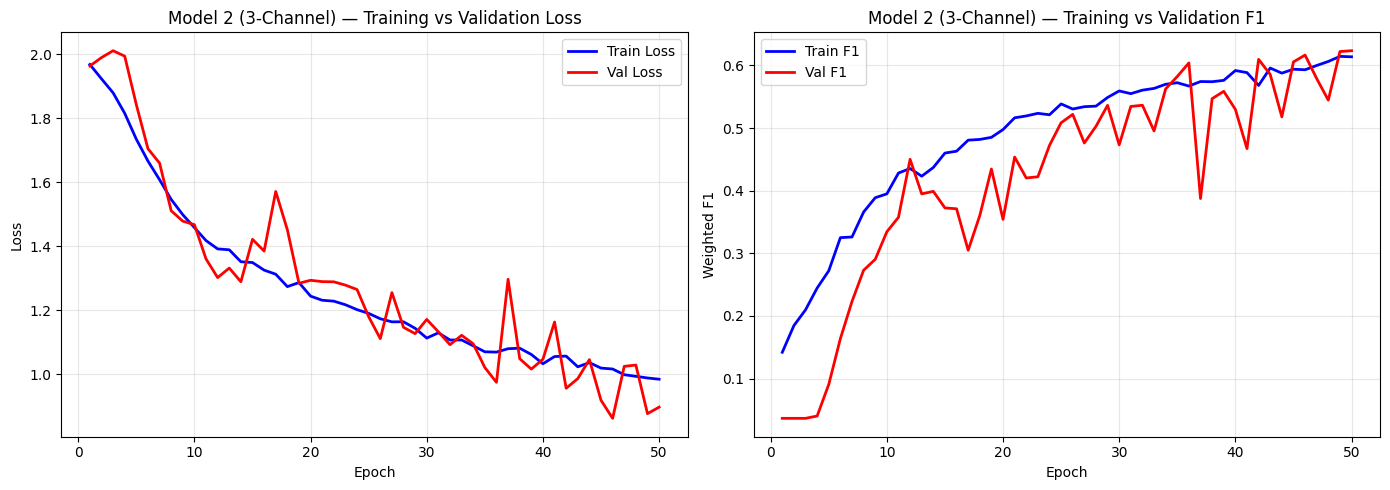

In [13]:
plot_training_curves(train_losses, val_losses, train_f1s, val_f1s,
                        save_path=os.path.join("model2_training_curves.png"))

In [14]:
# Final test evaluation
print("\n" + "=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)
model.load_state_dict(torch.load(best_model_path, weights_only=True))
test_loss, test_f1, test_preds, test_labels = validate(model, test_loader, criterion, DEVICE)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Weighted F1: {test_f1:.4f}")


FINAL EVALUATION ON TEST SET

Test Loss: 1.8623
Test Weighted F1: 0.2240


In [15]:
# Load label names
label_names = [str(i) for i in range(NUM_CLASSES)]
if os.path.exists("label_map.json"):
    with open("label_map.json", "r") as f:
        label_data = json.load(f)
    if "int_to_label" in label_data:
        int_to_label = label_data["int_to_label"]
    else:
        int_to_label = {str(v): k for k, v in label_data.items()}
    label_names = [int_to_label[str(i)] for i in range(NUM_CLASSES)]

print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

       angry       0.27      0.49      0.35        47
     disgust       0.00      0.00      0.00        47
     fearful       0.39      0.34      0.36        47
       happy       0.00      0.00      0.00        47
     neutral       0.27      1.00      0.42        46
         sad       0.25      0.09      0.13        47
   surprised       0.90      0.19      0.32        47

    accuracy                           0.30       328
   macro avg       0.30      0.30      0.22       328
weighted avg       0.30      0.30      0.22       328



Saved confusion matrix to model2_confusion_matrix.png


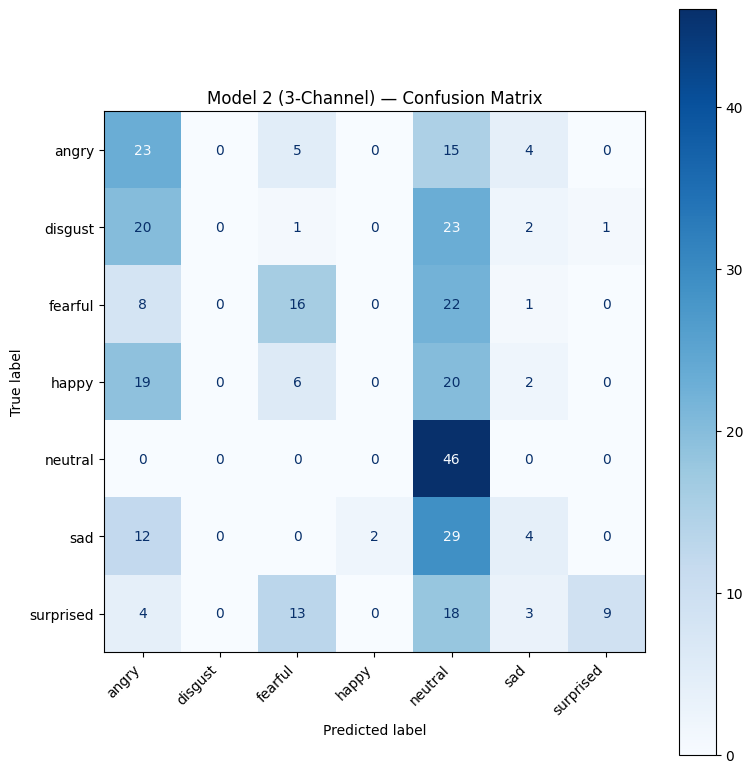

In [16]:
plot_confusion_matrix(test_labels, test_preds, label_names,
                        save_path=os.path.join("model2_confusion_matrix.png"))

In [17]:
print(f"\nPrediction distribution: {Counter(test_preds)}")
print(f"Actual distribution:     {Counter(test_labels)}")


Prediction distribution: Counter({np.int64(4): 173, np.int64(0): 86, np.int64(2): 41, np.int64(5): 16, np.int64(6): 10, np.int64(3): 2})
Actual distribution:     Counter({np.int64(3): 47, np.int64(5): 47, np.int64(0): 47, np.int64(2): 47, np.int64(1): 47, np.int64(6): 47, np.int64(4): 46})


In [18]:
# Save results
results = {
    "model": "CNN_Model2_3Channel",
    "input": "mel_spectrogram_3channel",
    "best_val_f1": round(best_val_f1, 4),
    "test_f1": round(test_f1, 4),
    "test_loss": round(test_loss, 4),
    "total_params": total_params,
    "epochs_trained": len(train_losses),
}
with open(os.path.join("model2_results.json"), "w") as f:
    json.dump(results, f, indent=2)
print(f"\nResults: {json.dumps(results, indent=2)}")


Results: {
  "model": "CNN_Model2_3Channel",
  "input": "mel_spectrogram_3channel",
  "best_val_f1": 0.6236,
  "test_f1": 0.224,
  "test_loss": 1.8623,
  "total_params": 423175,
  "epochs_trained": 50
}


In [20]:
# Compare to Model 1
model1_path = os.path.join("1channel_cnn_results.json")
if os.path.exists(model1_path):
    with open(model1_path) as f:
        m1 = json.load(f)
    print("\n" + "=" * 60)
    print("COMPARISON: Model 1 (1-channel) vs Model 2 (3-channel)")
    print("=" * 60)
    print(f"{'Metric':<20} {'Model 1':>12} {'Model 2':>12} {'Diff':>10}")
    print("-" * 60)
    print(f"{'Best Val F1':<20} {m1['best_val_f1']:>12.4f} {best_val_f1:>12.4f} {best_val_f1 - m1['best_val_f1']:>+10.4f}")
    print(f"{'Test F1':<20} {m1['test_f1']:>12.4f} {test_f1:>12.4f} {test_f1 - m1['test_f1']:>+10.4f}")
    print(f"{'Parameters':<20} {m1['total_params']:>12,} {total_params:>12,}")


COMPARISON: Model 1 (1-channel) vs Model 2 (3-channel)
Metric                    Model 1      Model 2       Diff
------------------------------------------------------------
Best Val F1                0.7137       0.6236    -0.0901
Test F1                    0.2169       0.2240    +0.0071
Parameters                422,599      423,175


# Model Results Discussion

Adding rate-of-change channels did NOT meaningfully improve speech emotion recognition on truly unseen speakers. The test F1 difference (+0.007) is statistical noise.

Both models hit the exact same wall on the test set (0.22 F1). The 3-channel version actually does worse on validation but generalizes just barely better, which suggests the delta features are slightly more speaker-invariant but not enough to matter.

The per-class failure pattern is identical: both models collapse onto "neutral" (89–100% recall, ~30% precision), both completely fail on "disgust" and "happy" (0% across the board), and both show high precision but very low recall on "surprised" (they only predict surprised when extremely confident).

The 3-channel hypothesis was wrong. Theory suggested that explicitly encoding rate-of-change should help capture emotion dynamics. Empirically, it didn't. The CNN with just the static spectrogram already extracts whatever rate-of-change information it needs.
The bottleneck is speaker generalization, not the input representation. Both models learn the same patterns from training and fail in the same ways on new speakers. Changing the input doesn't fix this.

The val-test gap is the actual finding of this entire project. The training pipeline works, but the model is learning speaker-specific emotion expressions rather than universal emotion features.